# 07 — Monomer versus dimer, and a bar that measures the target

A second experiment, absent from the earlier repository: the same drugs modelled against the
same targets with interface-specific metrics — `Ligand_ipTM`, `Interface_PDE`,
`Interface_pLDDT`. It was run to check whether the interface scores would behave better than
the global confidence score. The answer is interesting and not the one that was wanted.

In [1]:
import sys, os
from pathlib import Path

# Work from the repository root wherever the notebook is launched from.
_root = Path.cwd().resolve()
while not (_root / "src" / "offtarget").exists():
    _root = _root.parent
os.chdir(_root)
sys.path.insert(0, str(_root / "src"))

import pandas as pd
import yaml
from pathlib import Path
from offtarget import figures as F

pd.set_option("display.width", 140)
dimer = pd.read_parquet("data/processed/dimer_panel.parquet")
print(f"{len(dimer)} modelled pairs across {dimer.Target.nunique()} targets")
dimer.groupby(["sheet", "Target"]).size().to_frame("pairs")

107 modelled pairs across 8 targets


pairs
sheet        Target        
MAOA         MAOA        24
Raw          ADRA1A      13
             AR          13
             PTGS1       10
             SLC6A2      15
Transporters SLC29A1      2
             SLC6A3      14
             SLC6A4      16

## Three sheets, two defects

The workbook splits one experiment across sheets that grew as it ran: `Raw` (four targets),
`MAOA`, and `Transporters`. A fourth sheet, `-PDE>5`, is `Raw` again with a filter applied
and seven blank rows — reading it would double-count 51 of the 107 pairs, so `pipeline.py`
does not.

Two defects are repaired on the way in. `Raw` has a column-shift: 15 SLC6A2 rows carry a
**SMILES string** in the `Experiment result` column, a paste that landed one column to the
left. The `MAOA` sheet has no label column at all. Both are recovered by joining back to the
master table on (target, drug) rather than by retyping values into a spreadsheet.

In [2]:
raw = pd.read_excel("data/boltz_outputs/PDBdimerresult.xlsx", sheet_name="Raw")
raw.columns = [c.strip() for c in raw.columns]
bad = raw[~raw["Experiment result"].astype(str).str.lower().isin(
    ["inactive", "true positive", "nan"])]
print(f"{len(bad)} rows with a SMILES string in the label column")
bad[["Target", "Drug", "Experiment result"]].head(5)

15 rows with a SMILES string in the label column


,Target,Drug,Experiment result
36,SLC6A2,8HFE_Atropine,CN1C2CCC1CC(C2)OC(=O)C(CO)C3=CC=CC=C3
37,SLC6A2,8HFE_Bevantolol,CC1=CC(=CC=C1)OCC(CNCCC2=CC(=C(C=C2)OC)OC)O
38,SLC6A2,8HFE_Bisoprolol,CC(C)NCC(COC1=CC=C(C=C1)COCCOC(C)C)O
39,SLC6A2,8HFE_Buphenin,CC(CCC1=CC=CC=C1)NC(C)C(C2=CC=C(C=C2)O)O
40,SLC6A2,8HFE_Chlophedianol,CN(C)CCC(C1=CC=CC=C1)(C2=CC=CC=C2Cl)O


In [3]:
print(f"labels recovered: {int(dimer.label.notna().sum())} of {len(dimer)}")
dimer.label.value_counts(dropna=False).to_frame("rows")

labels recovered: 107 of 107


,rows
label,
assay_inactive,81
assay_active,26


## The pass rate is a property of the target

The bar cited in the March 2026 work as indicating crystal-structure-quality interface
prediction was `Interface_PDE < 1` and `Ligand_ipTM > 0.9`.

In [4]:
d = dimer.dropna(subset=["Ligand_ipTM", "Interface_PDE"]).copy()
d["clears_bar"] = (d.Interface_PDE < 1) & (d.Ligand_ipTM > 0.9)
summary = d.groupby("Target").agg(n=("drug", "size"), passed=("clears_bar", "sum"),
                                  median_ipDE=("Interface_PDE", "median"),
                                  median_ipTM=("Ligand_ipTM", "median"))
summary["pass_rate"] = (summary.passed / summary.n).round(2)
summary.sort_values("pass_rate", ascending=False).round(3)

,n,passed,median_ipDE,median_ipTM,pass_rate
Target,,,,,
SLC29A1,2,2,0.708,0.968,1.00
SLC6A4,16,7,1.009,0.966,0.44
MAOA,24,10,1.095,0.962,0.42
PTGS1,10,2,1.711,0.910,0.20
ADRA1A,13,0,5.281,0.896,0.00
AR,13,0,4.588,0.946,0.00
SLC6A2,15,0,6.489,0.916,0.00
SLC6A3,14,0,3.538,0.826,0.00


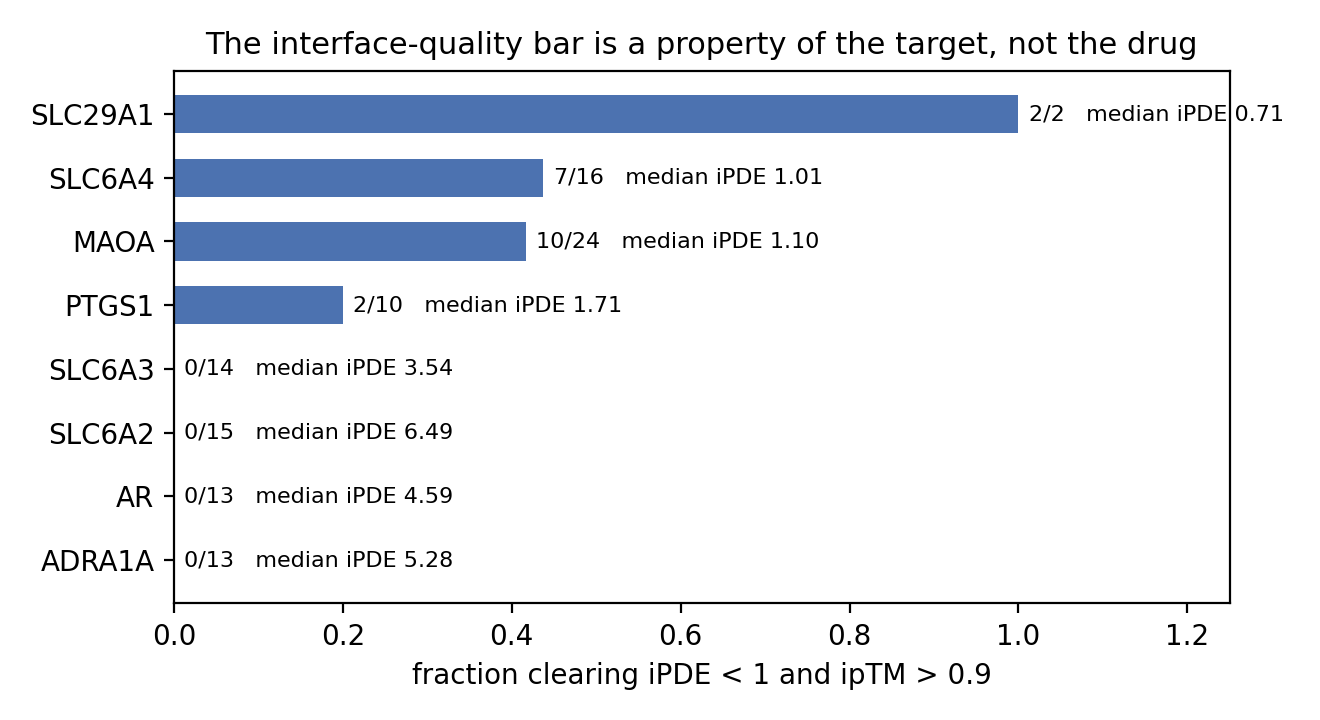

In [5]:
F.dimer_pass_rates(d, Path("results/figures/fig4_dimer_pass_rates.png"))
from IPython.display import Image, display
display(Image("results/figures/fig4_dimer_pass_rates.png"))

**SLC29A1 passes 2 of 2. SLC6A4 passes 7 of 16. MAOA passes 10 of 24. SLC6A3 passes 0 of 14**,
with a median interface PDE of 3.54 — well outside the bar, for every drug tested.

SLC6A3 and SLC6A4 are the same transporter family with the same fold. One of them fails
completely and the other passes about half the time. Whatever this bar measures, it is
tracking the target rather than the drug — which makes it useless for the job it was used
for, which was picking out drugs.

## The pass rate tracks the modelled oligomeric state

Joining the pass rate to what `targets.yaml` says was actually modelled explains most of the
spread across targets.

In [6]:
state = {t: v["arms"]["pdb"]["oligomeric_state"]
         for t, v in yaml.safe_load(Path("inputs/targets.yaml").read_text())["targets"].items()
         if "pdb" in v["arms"]}
d["modelled_as"] = d.Target.map(state)
d.groupby(["modelled_as", "Target"]).agg(n=("drug", "size"), passed=("clears_bar", "sum"),
                                         median_ipDE=("Interface_PDE", "median")).round(2)

n  passed  median_ipDE
modelled_as Target                          
homodimer   ADRA1A   13       0         5.28
            AR       13       0         4.59
            PTGS1    10       2         1.71
            SLC6A2   15       0         6.49
monomer     MAOA     24      10         1.10
            SLC29A1   2       2         0.71
            SLC6A3   14       0         3.54
            SLC6A4   16       7         1.01

In [7]:
by_state = d.groupby("modelled_as").agg(n=("drug", "size"), passed=("clears_bar", "sum"),
                                        median_ipDE=("Interface_PDE", "median"),
                                        median_ipTM=("Ligand_ipTM", "median"))
by_state["pass_rate"] = (by_state.passed / by_state.n).round(3)
by_state.round(3)

,n,passed,median_ipDE,median_ipTM,pass_rate
modelled_as,,,,,
homodimer,51,2,5.281,0.916,0.039
monomer,56,19,1.179,0.961,0.339


**Inputs modelled as homodimers pass 2 of 51 (4%). Inputs modelled as monomers pass 19 of 56
(34%).** Median interface PDE is 5.28 for the dimers against 1.18 for the monomers.

There is a mechanical reading of this that fits: given two protein chains, the interface
metrics have a large protein–protein interface to describe as well as the ligand pocket, and
the reported value is no longer about the ligand. That would explain why a bar built from
these metrics tracks the target rather than the drug — the dimers are the targets that fail.

This is an association across eight targets with oligomeric state assigned by hand, not a
controlled experiment, and it cannot separate oligomeric state from target identity. It is
the hypothesis that fits, offered as one.

## Do the interface metrics discriminate at all?

The reason for running this experiment was the hope that interface-specific metrics would
succeed where the global confidence score failed. They do not.

In [8]:
from offtarget.metrics import stratified_auc
labelled = d[d.label.notna()].copy()
labelled["neg_interface_PDE"] = -labelled.Interface_PDE
print(f"n = {len(labelled)}   "
      f"assay-active = {int((labelled.label == 'assay_active').sum())}")
pd.DataFrame([{"score": c, "within-target AUC": round(stratified_auc(labelled, c)[0], 3),
               "targets used": stratified_auc(labelled, c)[1]}
              for c in ["Ligand_ipTM", "neg_interface_PDE", "Interface_pLDDT"]])

n = 107   assay-active = 26


,score,within-target AUC,targets used
0,Ligand_ipTM,0.488,6
1,neg_interface_PDE,0.502,6
2,Interface_pLDDT,0.493,6


All three sit at chance: **0.488, 0.502, 0.493**. This is a separate set of metrics from a
separate set of runs, and it reaches the same place as notebook 03. The problem is not that
the wrong confidence number was read; every structural quality score available here fails to
separate confirmed binders from confirmed non-binders on this dataset.

## And the targets differ in their inputs

From the audit in notebook 02: SLC6A4's input is the canonical sequence plus 55 residues of
purification scaffold, modelled as a monomer. SLC6A3's input aligns to only 67% of the human
dopamine transporter — 22 substitutions, 91 inserted residues in nine blocks — also modelled
as a monomer. Meanwhile SLC6A2, the third member of the same family, is modelled as a
**homodimer**.

In [9]:
cfg = yaml.safe_load(Path("inputs/targets.yaml").read_text())
rows = []
for t in ["SLC6A2", "SLC6A3", "SLC6A4"]:
    for arm_name, arm in cfg["targets"][t]["arms"].items():
        rows.append({"target": t, "arm": arm_name, "pdb": arm["pdb_id"],
                     "oligomeric state": arm["oligomeric_state"],
                     "identity to canonical": arm["audit"]["identity_to_canonical"],
                     "inserted residues": arm["audit"]["inserted_residues"],
                     "tags": ", ".join(arm["audit"]["construct_tags"]) or "—"})
pd.DataFrame(rows)

,target,arm,pdb,oligomeric state,identity to canonical,inserted residues,tags
0,SLC6A2,pdb,8HFE,homodimer,1.000,0,—
1,SLC6A2,uniprot,None,homodimer,1.000,0,—
2,SLC6A3,pdb,8Y2G,monomer,0.673,91,—
3,SLC6A4,pdb,9HCO,monomer,0.920,55,"GS-linker, His-tag, Strep-tag, thrombin"


Three members of one transporter family, three different modelling decisions, no stated
rule for any of them — and the metric they are being scored on varies more across those
three targets than it does across the drugs being tested.

This is a confounded comparison, not a controlled experiment: oligomeric state, construct
identity and target are varied together, and there are five targets. It cannot attribute the
effect to oligomeric state. What it does establish is that **the interface bar was reading
something other than ligand binding**, which is enough to disqualify it as a nomination
criterion in notebook 06.